In [12]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df_train = pd.read_csv('/content/loan-train.csv')

label_encoder = LabelEncoder()
df_train['Loan_Status'] = label_encoder.fit_transform(df_train['Loan_Status'])
df_train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


In [13]:
loan_status_classes = df_train['Loan_Status'].unique()
print(loan_status_classes)

[1 0]


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

numeric_features = df_train.select_dtypes(include='number').drop(columns=['Loan_Status'])
target = df_train['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(numeric_features, target, test_size=0.1, random_state=42)

model = RandomForestClassifier(n_estimators=100) # random_state=42
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

accuracy

0.7258064516129032

In [15]:
model_2 = RandomForestClassifier(max_depth=5, random_state=42)
model_2.fit(X_train, y_train)

y_pred_2 = model_2.predict(X_test)
accuracy_2 = accuracy_score(y_test, y_pred_2)

accuracy_2

0.7419354838709677

In [16]:
model_3 = RandomForestClassifier(max_depth=10, random_state=42)
model_3.fit(X_train, y_train)

y_pred_3 = model_3.predict(X_test)
accuracy_3 = accuracy_score(y_test, y_pred_3)

accuracy_3

0.7419354838709677

In [17]:
feature_importances = model_3.feature_importances_
feature_names = numeric_features.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

print(importance_df)

             Feature  Importance
0    ApplicantIncome    0.205719
1  CoapplicantIncome    0.136416
2         LoanAmount    0.198313
3   Loan_Amount_Term    0.065473
4     Credit_History    0.394080


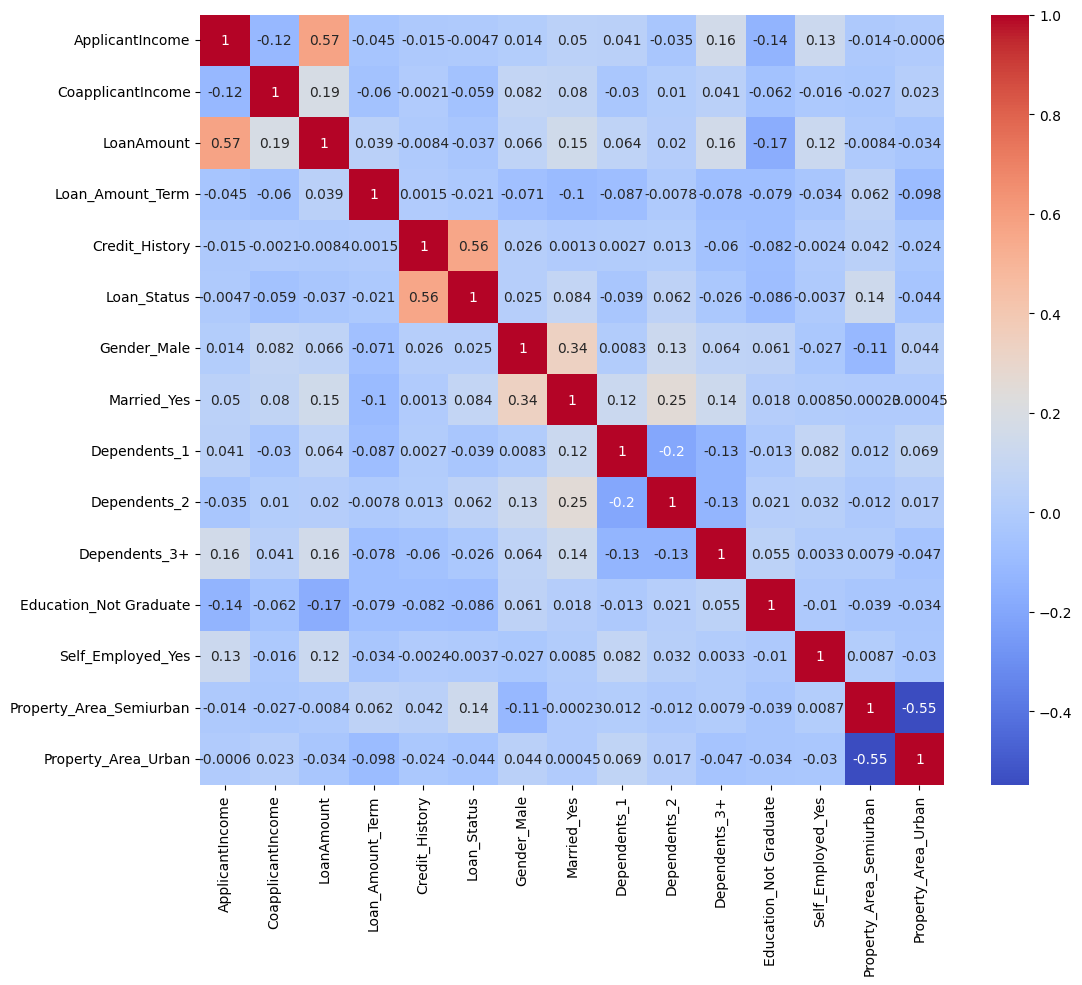

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

df_train_2 = df_train.drop(columns=['Loan_ID'])
df_train_2 = pd.get_dummies(df_train_2, drop_first=True)

correlation_matrix = df_train_2.corr()
plt.figure(figsize=(12,10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

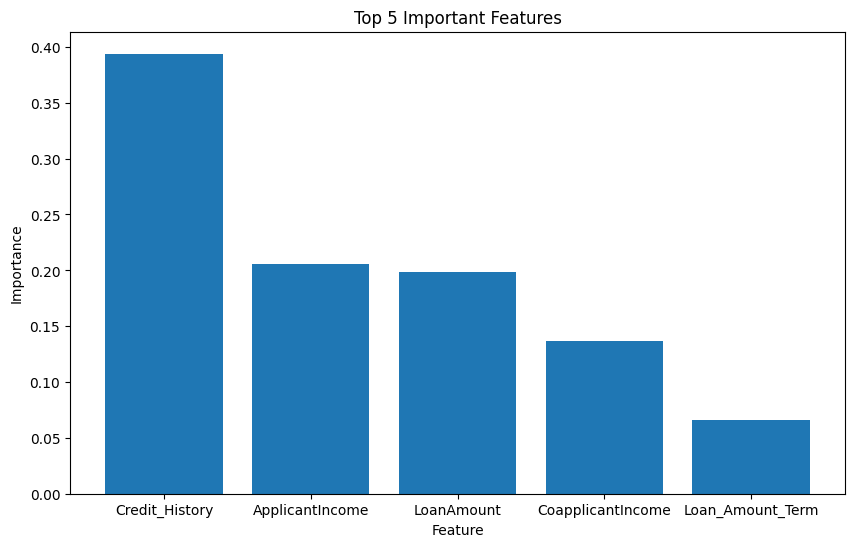

In [19]:
important_features = importance_df.sort_values(by='Importance', ascending=False).head(5)
plt.figure(figsize=(10,6))
plt.bar(important_features['Feature'], important_features['Importance'])
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Top 5 Important Features')
plt.show()

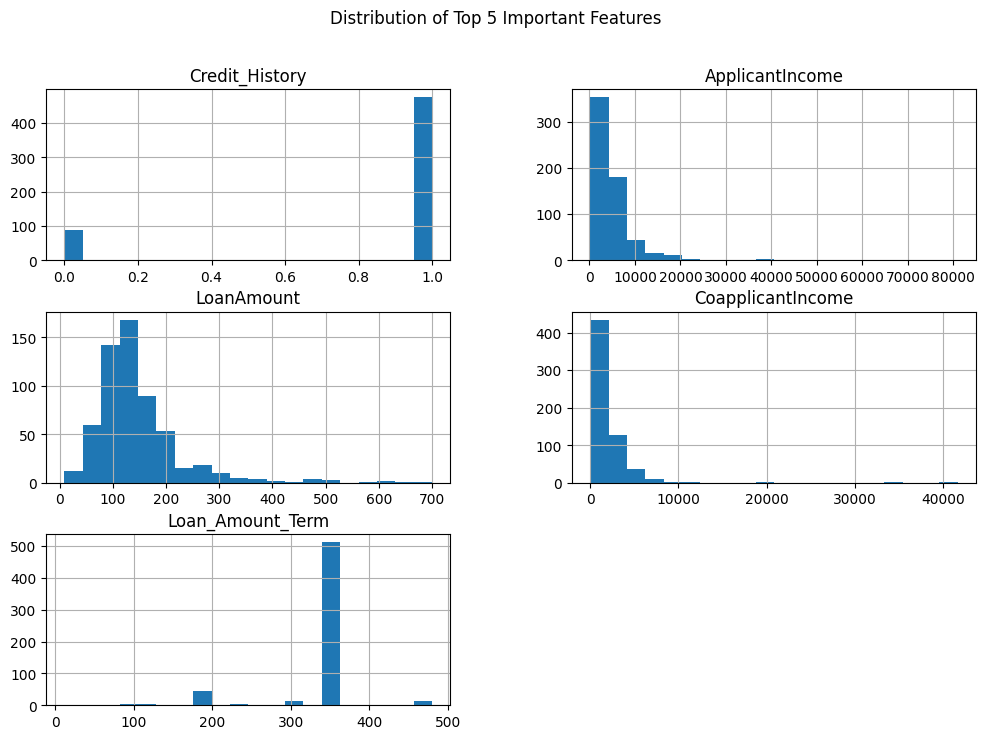

In [22]:
df_train[important_features['Feature']].hist(bins=20, figsize=(12, 8))
plt.suptitle("Distribution of Top 5 Important Features")
plt.show()

In [21]:
from sklearn.tree import DecisionTreeClassifier

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(numeric_features, target, test_size=0.1, random_state=42)

dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train_2, y_train_2)

y_pred_dt = dt_model.predict(X_test_2)
accuracy_dt = accuracy_score(y_test_2, y_pred_dt)

accuracy_dt

0.6774193548387096

**I found out that 'Credit_History'was the most influencial factor in predicting loan approval. 'ApplicantIncome', 'LoanAmount', and 'CoapplicantIncome' followed after that. These features indicates that both credit reliability and levels of income affects the loan eligibility. The correlation analysis showed that applicants with positive credit histories with higher incomes are more likely to be approved. Visualizations including some historgrams and graphs showed that most applicants that have low income applied for smaller loans, maintaining a positive credit history.**

**I used Random Forest Classifer and Decision Tree model in my mini project. From these two models, Random Forest Classifier performed better, achieving and accuracy of about 74% where Decision Tree model achieved the accuracy of about 67%. This indicates that ensemble methods such as Random Forest well suits this case, handling feature importance effectively. To wrap up,this project highlights the importance of credit history and income when deciding loans. Following each steps, I learned that it's really important to know the value of model selection, preprocessing the data, and analyzing feature to make predictive models.**